# Проект: Разработка A/B-тестирования и анализ результатов

* Автор: Филимонова Мария
* Дата: 02.04

### Цели и задачи проекта

**Цель:** Оценить эффективность нового алгоритма рекомендаций, направленного на повышение вовлечённости пользователей в мобильном приложении.

**Задачи:**

- Загрузка и первичный анализ данных

- Исследовательский анализ исторических данных

- Формулировка гипотез

- Проектирование A/B-теста

- Проверка корректности рандомизации

- Анализ целевой метрики

- Интерпретация результатов и формулировка выводов

### Описание данных

Данные состоят из трех датасетов:

- `sessions_project_history.csv` - таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23

- `sessions_project_test_part.csv` - таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14

- `sessions_project_test.csv` - таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;
- `session_id` — идентификатор сессии в приложении;
- `session_date` — дата сессии;
- `session_start_ts` — дата и время начала сессии;
- `install_date` — дата установки приложения;
- `session_number` — порядковый номер сессии для конкретного пользователя;
- `registration_flag` — является ли пользователь зарегистрированным;
- `page_counter` — количество просмотренных страниц во время сессии;
- `region` — регион пользователя;
- `device` — тип устройства пользователя;
- `test_group` — тестовая группа.

### Содержимое проекта

1. Работа с историческими даннымы (EDA)
2. Подготовка к тесту
3. Мониторинг A/B-теста
4. Проверка результатов A/B-теста

## 1. Работа с историческими даннымы (EDA)

### 1.1. Загрузка исторических данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

from math import ceil

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

In [2]:
# Выгружаем данные в переменную sessions_history
try:
    sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
except FileNotFoundError:
    sessions_history = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Развлекательное приложение/sessions_project_history.csv')

Познакомимся с данными датасета `sessions_history.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [4]:
# Выводим информацию о датафрейме
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


Датасет `sessions_history.csv` содержит 10 столбцов и 435924 строки, в котором представлена информация об исторических данных по сессиям пользователей на период с 2025-08-11 по 2025-09-23

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Пропусков в данном датасет нет

### 1.2. Знакомство с данными

In [5]:
# Расчитаем количество уникальных сессий для каждого уникального пользователя
sessions_user_id = sessions_history.groupby('user_id')['session_id'].nunique()

# Выводим результат
print(f'Количество уникальных сессий для каждого уникального user_id')
print(sessions_user_id.head())

Количество уникальных сессий для каждого уникального user_id
user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
Name: session_id, dtype: int64


In [6]:
# Находим ID пользователя с максимальным количеством сессий
user_max = sessions_user_id.idxmax()

# Выводим результат
print(f'Пользователь с наибольшим количеством сессий: {user_max}')

Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0


In [7]:
# Находим историю сессий для пользователя с максимальным числом сессий
user_data = sessions_history[sessions_history['user_id'] == user_max]

# Выводим результат
user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### 1.3. Анализ числа регистраций

In [8]:
# Преобразуем столбец session_date в тип данных даты и времени
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [9]:
# Группируем данные по дате сессии, считаем уникальных пользователей и зарегистрированных
days_stats = sessions_history.groupby('session_date').agg(total_users = ('user_id', 'nunique'),
                                                          reg_users = ('registration_flag', 'sum')).reset_index()

# Выводим первые 10 строк
days_stats.head(10)

,session_date,total_users,reg_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840
5,2025-08-16,12205,916
6,2025-08-17,11200,833
7,2025-08-18,10839,860
8,2025-08-19,12118,831
9,2025-08-20,13514,1008


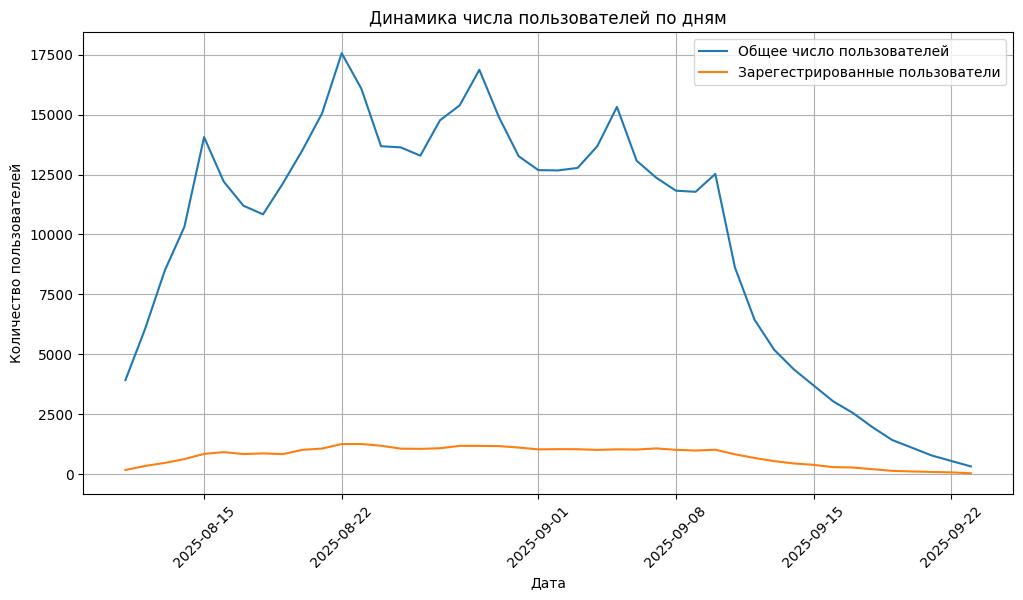

In [10]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим линейный график 1
plt.plot(days_stats['session_date'], 
         days_stats['total_users'], 
         label='Общее число пользователей'
         )

# Строим линейный график 2
plt.plot(days_stats['session_date'],
         days_stats['reg_users'],
         label='Зарегестрированные пользователи'
         )

# Настраиваем оформление графика
plt.title('Динамика числа пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.xticks(rotation=45)

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Период роста (15–22 августа): резкий приток пользователей, возможно, связанный с маркетинговой активностью, запуском акции или улучшением функционала сервиса

- Период колебаний (22 августа — 8 сентября): после пика активность стабилизируется с волнообразными колебаниями

- Период спада (после 8 сентября): устойчивое снижение как общего числа пользователей, так и числа зарегистрированных

- Количество зарегистрированных пользователей значительно ниже общего числа (на порядок меньше — в диапазоне 0–1 500)

- Кривая зарегистрированных пользователей более стабильная по сравнению с общей динамикой — без резких пиков и спадов

In [11]:
# Рассчитываем процент зарегистрированных пользователей от общего числа
days_stats['reg_rate'] = days_stats['reg_users'] / days_stats['total_users']

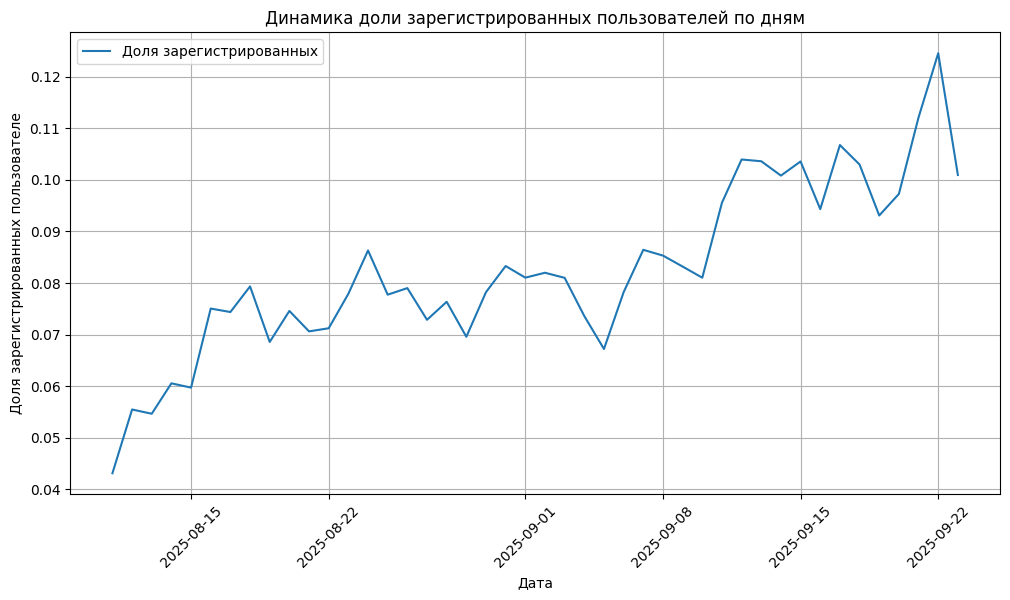

In [12]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим линейный график
plt.plot(days_stats['session_date'],
        days_stats['reg_rate'],
        label='Доля зарегистрированных'
         )

# Настраиваем оформление графика
plt.title('Динамика доли зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователе')
plt.legend()
plt.xticks(rotation=45)

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- На графике прослеживается неравномерная динамика доли зарегистрированных пользователей в период с 15 августа по 22 сентября 2025 года

- Начальная доля (около 0,04 в середине августа) постепенно растёт, демонстрируя тенденцию к увеличению активности регистрации

- К концу периода (22 сентября) наблюдается пиковый показатель — около 0,12, что является максимальным значением за весь анализируемый срок.

### 1.4. Анализ числа просмотренных страниц

In [13]:
# Подсчитываем, сколько раз встречается каждое значение счётчика страниц
page_counts = sessions_history['page_counter'].value_counts()

# Выводим результат
page_counts

page_counter
3    166690
4    105569
2    105536
1     29160
5     26288
6      2589
7        92
Name: count, dtype: int64

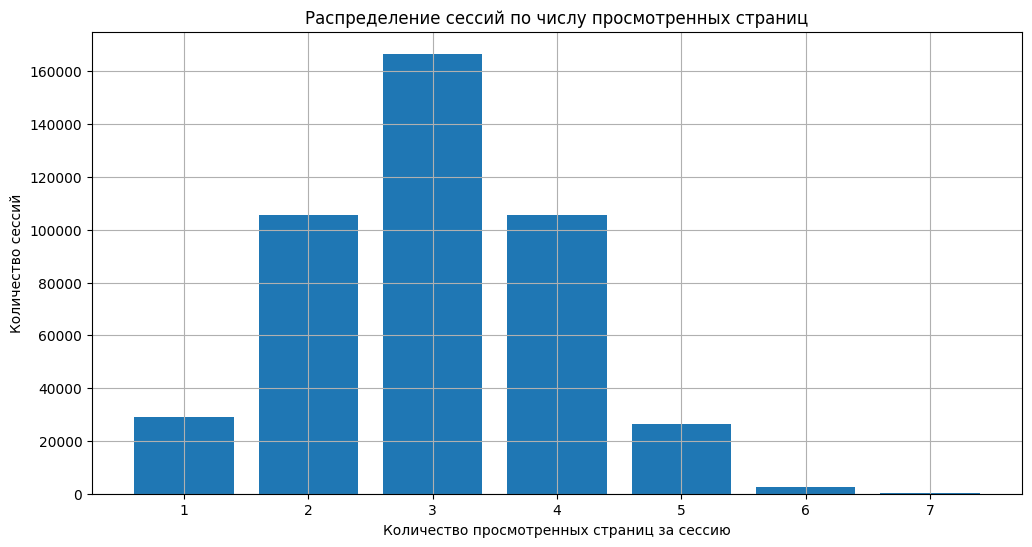

In [14]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму
plt.bar(page_counts.index,
        page_counts.values)

# Настраиваем оформление графика
plt.title('Распределение сессий по числу просмотренных страниц')
plt.xlabel('Количество просмотренных страниц за сессию')
plt.ylabel('Количество сессий')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- График демонстрирует неравномерное распределение сессий по количеству просмотренных страниц

- Максимальное количество сессий (около 160 000) приходится на сессии, в которых пользователи просматривают 3 страницы

- Второй по величине пик (около 105 000 сессий) наблюдается при просмотре 2 и 4 страниц 

- Минимальное количество сессий приходится на 6 и 7 просмотренных страниц

### 1.5. Доля пользователей, просмотревиших более четырех страниц

In [15]:
# Создаем столбец good_session
sessions_history['good_session'] = 0
sessions_history.loc[sessions_history['page_counter'] >= 4, 'good_session'] = 1

In [16]:
# Выбираем те строк, в которых session_number равен 1
first_session = sessions_history[sessions_history['session_number'] == 1].copy()

# Группируем строки по дате сессии
daily_first = first_session.groupby('session_date').agg(total_first_session = ('good_session', 'size'),
                                                        good_first_session = ('good_session', 'sum')).reset_index()

In [17]:
# Расчитываем долю успешных сессий
daily_first['good_rate'] = daily_first['good_first_session'] / daily_first['total_first_session']

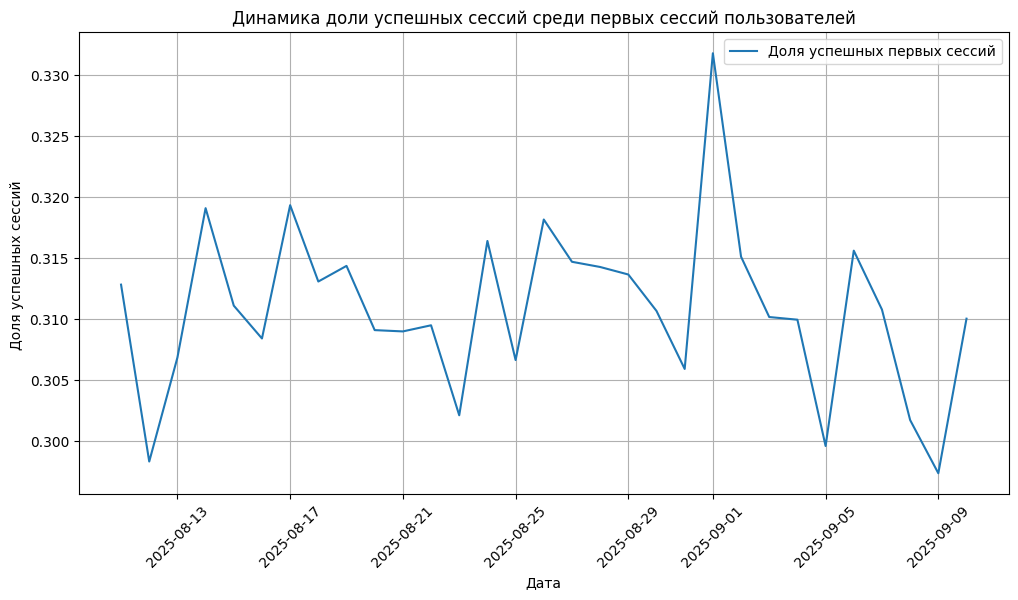

In [18]:
# Задаем размер графика
plt.figure(figsize=(12, 6))

# Строим линейный график
plt.plot(daily_first['session_date'],
         daily_first['good_rate'],
         label = 'Доля успешных первых сессий')

# Настраиваем оформление графика
plt.title('Динамика доли успешных сессий среди первых сессий пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий ')
plt.legend()
plt.xticks(rotation=45)

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- График демонстрирует динамику доли «успешных» первых сессий (где пользователь просмотрел 4 и более страниц) в период с 13 августа по 9 сентября 2025 года

- Динамика носит волнообразный характер с периодическими всплесками и спадами

- Отсутствуют длительные тренды — преобладает краткосрочная изменчивость, что может указывать на влияние случайных факторов

## 2. Подготовка к тесту

#### Целевая метрика: Доля успешных первых сессий среди новых пользователей

### 2.1. Расчет размера выборки

In [19]:
# Задаем параметры
alpha = 0.05 
beta = 0.2  
power = 1 - beta  
p = 0.3 
mde = p * 0.03  
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 
)

# Выводим результат
print(f'Необходимый размер выборки для каждой группы: {int(sample_size)}')

Необходимый размер выборки для каждой группы: 41040


### 2.2. Расчёт длительности A/B-теста

In [20]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = days_stats['total_users'].mean().round(0)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

# Выводим результат
print(f'Рассчитанная длительность A/B-теста при текущем уровене трафика в {int(avg_daily_users)} пользователей в день составит {test_duration} дней')

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907 пользователей в день составит 9 дней


## 3. Мониторинг A/B-теста

### 3.1. Проверка распределения пользователей

In [21]:
# Выгружаем данные в переменную sessions_test_part
try:
    sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
except:
    sessions_test_part = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Развлекательное приложение/sessions_project_test_part.csv')

In [22]:
# Выводим первые строки датафрейма на экран
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [23]:
# Выводим информацию о датафрейме
sessions_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


Датасет `sessions_test_part.csv` содержит 11 столбцов и 3130 строк, в котором представлена информация о данных за первый день проведения A/B-теста, то есть за 2025-10-14

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Пропусков в данном датасет нет

In [24]:
# Посмотрим, какие группы встречаются в эксперементе
sessions_test_part['test_group'].unique()

array(['B', 'A'], dtype=object)

В эксперементе две группы - `A` и `B`. Рассчиатем количество уникальных пользователей в каждой группе

In [25]:
# Расчитаем количество уникальных пользователей в каждой группе
group_counts = sessions_test_part.groupby('test_group')['user_id'].nunique()

# Выводим результат
group_counts

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [26]:
# Получаем количество пользователей в группах A и B 
users_A = group_counts.get('A', 0)
users_B = group_counts.get('B', 0)

# Рассчитаем процентную разницу в количестве пользователей в группах A и B
percent_diff = 100 * abs(users_A - users_B) / users_A

# Выводим результат
print(f'Процентная разница (относительно группы A): {percent_diff:.2f}%')

Процентная разница (относительно группы A): 0.74%


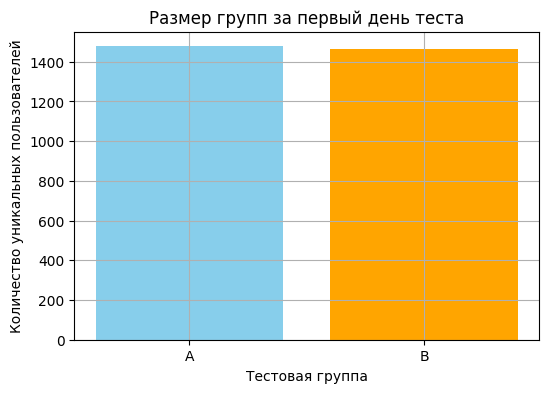

In [27]:
# Задаем размер графика
plt.figure(figsize=(6, 4))

# Строим столбчатую диаграмму
plt.bar(group_counts.index, 
        group_counts.values,
        color=['skyblue', 'orange'])

# Настраиваем оформление графика
plt.xlabel('Тестовая группа')
plt.ylabel('Количество уникальных пользователей')
plt.title('Размер групп за первый день теста')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Размеры групп A и B практически равны — разница, если и присутствует, минимальна и не видна на визуальном уровне

- Равномерное распределение пользователей между группами является положительным фактором для тестирования, так как минимизирует риск смещения результатов из-за неравного количества участников

### 3.2. Проверка пересечений пользователей

In [28]:
# Проверим, есть ли пользователи, которые попали в обе группы
A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(A) & set(B))

# Выводим результат
print(intersection)

[]


**Вывод:**

В результате проверки выявлено, что нет пользователей, которые попали одновременно в обе тестовые группы (A и B)

### 3.3. Равномерность рампределения пользователей по устройствам

In [29]:
# Сгруппируем данные со сведениями об устройствах пользователей
users_devices = sessions_test_part.groupby(['user_id', 'test_group'])['device'].first().reset_index()

# Выводим результат
users_devices.head(10)

,user_id,test_group,device
0,00079359B9D3C6F7,A,iPhone
1,0022A97F43200059,B,PC
2,003F91666BF2969D,A,PC
3,004FAB6543185EEC,B,Android
4,0059B141C6958E32,A,Android
5,007871317205DA58,A,Android
6,00862F99B7413B65,A,Android
7,008EB177C06E974A,B,PC
8,00BF89BEF7357F44,A,Mac
9,00EAE308162261FB,A,iPhone


In [30]:
# Группируем данные для рассчета доли устройств в группах A и B
users_devices_a = users_devices[users_devices['test_group'] == 'A']['device'].value_counts(normalize=True)
users_devices_b = users_devices[users_devices['test_group'] == 'B']['device'].value_counts(normalize=True)

In [31]:
# Выводим результат
print('Группа A, доля устройств:')
print(users_devices_a)

Группа A, доля устройств:
device
Android    0.444144
PC         0.249831
iPhone     0.200406
Mac        0.105619
Name: proportion, dtype: float64


In [32]:
# Выводим результат
print('Группа B, доля устройств:')
print(users_devices_b)

Группа B, доля устройств:
device
Android    0.455662
PC         0.259891
iPhone     0.183492
Mac        0.100955
Name: proportion, dtype: float64


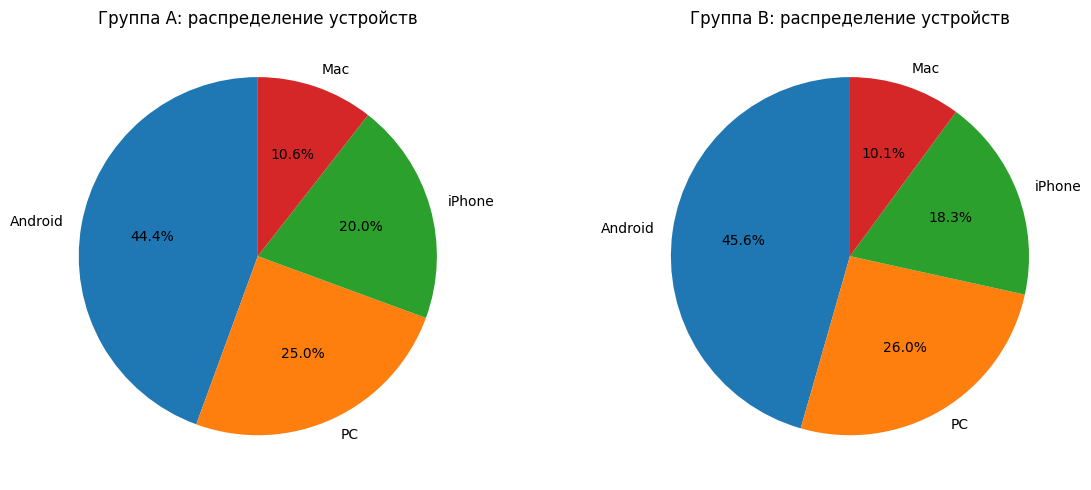

In [33]:
# Создаём фигуру с двумя подграфиками (1 строка, 2 колонки), размер 12x5 дюймов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Строим первую круговую диаграмму
axes[0].pie(users_devices_a, labels=users_devices_a.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Группа A: распределение устройств')

# Строим вторую круговую диаграмму
axes[1].pie(users_devices_b, labels=users_devices_b.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Группа B: распределение устройств')

# Автоматическая настройка отступов, чтобы элементы не налезали друг на друга
plt.tight_layout()

# Отображение графиков
plt.show()

**Вывод:**

Распределение устройств в обеих группах имеет схожий характер: доминируют мобильные платформы (Android), значительная доля приходится на ПК (PC), а устройства Mac и iPhone составляют меньшую часть выборки. Это говорит о сбалансированности групп с точки зрения типов устройств.

### 3.4. Равномерность рампределения пользователей по регионам

In [34]:
# Для каждого пользователя и его тестовой группы берём первый попавшийся регион
users_regions = sessions_test_part.groupby(['user_id', 'test_group'])['region'].first().reset_index()

# Выводим результат
users_regions.head(10)

,user_id,test_group,region
0,00079359B9D3C6F7,A,MENA
1,0022A97F43200059,B,CIS
2,003F91666BF2969D,A,CIS
3,004FAB6543185EEC,B,CIS
4,0059B141C6958E32,A,MENA
5,007871317205DA58,A,MENA
6,00862F99B7413B65,A,CIS
7,008EB177C06E974A,B,MENA
8,00BF89BEF7357F44,A,MENA
9,00EAE308162261FB,A,CIS


In [35]:
# Группируем данные для рассчета доли каждого региона в группах A и B
users_region_a = users_regions[users_regions['test_group'] == 'A']['region'].value_counts(normalize=True)
users_region_b = users_regions[users_regions['test_group'] == 'B']['region'].value_counts(normalize=True)

In [36]:
# Выводи результат для группы A
print('Группа A, доля каждого региона:')
print(users_region_a)

Группа A, доля каждого региона:
region
CIS     0.436019
MENA    0.412322
EU      0.151659
Name: proportion, dtype: float64


In [37]:
# Выводи результат для группы B
print('Группа B, доля каждого региона:')
print(users_region_b)

Группа B, доля каждого региона:
region
CIS     0.439973
MENA    0.412005
EU      0.148022
Name: proportion, dtype: float64


In [38]:
# Создаем датафрейм для визуализации
region_comp = pd.DataFrame({'A': users_region_a, 'B': users_region_b}).fillna(0)

<Figure size 1000x600 with 0 Axes>

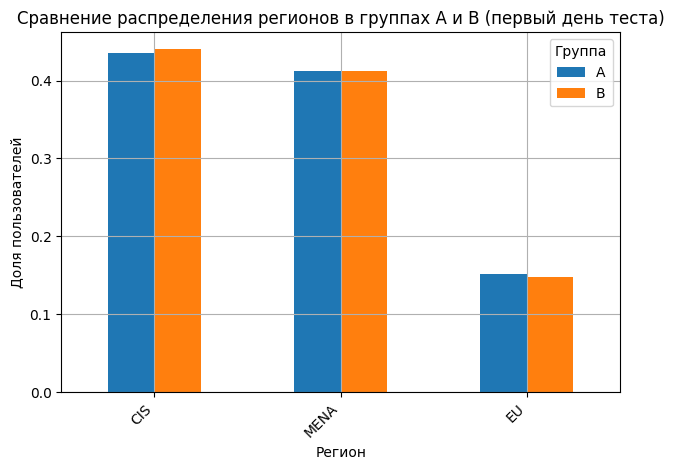

In [39]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
region_comp.plot(kind='bar')

# Настраиваем оформление графика
plt.xlabel('Регион')
plt.ylabel('Доля пользователей')
plt.title('Сравнение распределения регионов в группах A и B (первый день теста)')
plt.legend(title='Группа')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Распределение пользователей между группами A и B по всем регионам можно считать сбалансированным

- Доминирование C/S и MENA: эти регионы составляют основную массу пользователей 

- Малая доля EU: регион EU наименее представлен

### 3.5. Вывод после проверки A/B-теста

- Распределение пользователей по регионам оказалось сбалансированным

- Распределение по типам устройств также соответствовало ожидаемому уровню баланса, что подтвердило корректность механизма распределения пользователей

- Отсутствие пересечений пользователей между группами гарантировало чистоту эксперимента

## 4. Проверка результатов A/B-теста

### 4.1. Получение результатов теста и подсчёт основной метрики

In [40]:
# Выгружаем данные в переменную sessions_test
try:
    sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
except:
    sessions_test = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Развлекательное приложение/sessions_project_test.csv')

In [41]:
# Выводим первые строки датафрейма на экран
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [42]:
# Выводим информацию о датафрейме
sessions_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100005 non-null  object
 1   session_id         100005 non-null  object
 2   session_date       100005 non-null  object
 3   session_start_ts   100005 non-null  object
 4   install_date       100005 non-null  object
 5   session_number     100005 non-null  int64 
 6   registration_flag  100005 non-null  int64 
 7   page_counter       100005 non-null  int64 
 8   region             100005 non-null  object
 9   device             100005 non-null  object
 10  test_group         100005 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


Датасет `sessions_test.csv` содержит 11 столбцов и 100005 строк, в котором представлена информация о данных за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Пропусков в данном датасет нет

In [43]:
# Создаем столбец good_session
sessions_test['good_session'] = 0
sessions_test.loc[sessions_test['page_counter'] >= 4, 'good_session'] = 1

### 4.2. Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

**H<sub>0</sub> (нулевая гипотеза):** Доля успешных первых сессий среди новых пользователей не отличается между контрольной группой и экспериментальной группой

**H<sub>1</sub> (альтернативная гипотеза):** Доля успешных первых сессий среди новых пользователей статистически значимо выше в экспериментальной группе по сравнению с контрольной группой

**Прокси-метрика:** Количество просмотренных элементов

**Барьерная метрика:** Доля сессий с одним просмотром и быстрым выходом

### 4.3. Сравнение доли успешных сессий

In [44]:
# Выбираем те строк, в которых session_number равен 1
first_session = sessions_test[sessions_test['session_number'] == 1].copy()

In [45]:
# Группируем строки по названию группы
group_stat = first_session.groupby('test_group').agg(total_users = ('user_id', 'nunique'),
                                                    good_first = ('good_session', 'sum')).reset_index()

# Выводим результат
group_stat

,test_group,total_users,good_first
0,A,15162,4787
1,B,15416,4851


In [46]:
# Рассчитаем долю успешных первых сессий для выборок A и B
group_stat['good_rate'] = group_stat['good_first'] / group_stat['total_users']

# Выводим результат
group_stat

,test_group,total_users,good_first,good_rate
0,A,15162,4787,0.315724
1,B,15416,4851,0.314673


In [47]:
# Рассчитаем разницу 
rate_A = group_stat[group_stat['test_group'] == 'A']['good_rate'].values[0]
rate_B = group_stat[group_stat['test_group'] == 'B']['good_rate'].values[0]
diff = rate_B - rate_A

# Выводим результат
print(f'Разница (B - A): {diff:.4f}')

Разница (B - A): -0.0011


### 4.4. Насколько статистически значимо изменение ключевой метрики

In [48]:
# Посчитаем размер выборок
n_a = first_session[first_session['test_group'] == 'A']['user_id'].nunique()
n_b = first_session[first_session['test_group'] == 'B']['user_id'].nunique()

In [49]:
# Посчитаем количество "успехов" для каждой группы
m_a = first_session[(first_session['test_group'] == 'A') & (first_session['good_session'] == 1)]['user_id'].nunique()
m_b = first_session[(first_session['test_group'] == 'B') & (first_session['good_session'] == 1)]['user_id'].nunique()

In [50]:
# Рассчитаем доли успехов для каждой группы: A и B
p_a, p_b = m_a / n_a, m_b / n_b

# Выводим результат
print(f'Группа A: пользователей = {n_a}, успешных первых сессий = {m_a}, доля = {p_a:.4f}')
print(f'Группа B: пользователей = {n_b}, успешных первых сессий = {m_b}, доля = {p_b:.4f}')

Группа A: пользователей = 15162, успешных первых сессий = 4787, доля = 0.3157
Группа B: пользователей = 15416, успешных первых сессий = 4851, доля = 0.3147


In [51]:
# Проверка условия нормального приближения
if (p_a * n_a > 10) and ((1 - p_a) * n_a > 10) and (p_b * n_b > 10) and ((1 - p_b) * n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [52]:
# Задаем уровень значимости
alpha = 0.05

# Проводим z-тест
stat_ztest, p_value_ztest = proportions_ztest([m_a, m_b],
                                              [n_a, n_b], 
                                              alternative='smaller')

# Выводим значение pvalue
print(f'pvalue = {p_value_ztest}')

pvalue = 0.5783523649187868


In [53]:
# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if p_value_ztest > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Нет достаточных оснований для отклонения нулевой гипотезы


### 4.5. Вывод по результатам A/B-эксперимента

По результатам A/B-тестирования нового алгоритма рекомендаций можно сделать следующие выводы:

**Характеристики эксперимента:**

- Период проведения: 14 октября – 2 ноября 2025 года

- Целевая метрика: доля успешных первых сессий среди новых пользователей (успешная сессия – просмотр 4 и более страниц)

- Контрольная группа (А): 15 162 пользователя, старый алгоритм

- Экспериментальная группа (B): 15 416 пользователей, новый алгоритм

- Длительность: 20 дней

**Влияние на ключевую метрику:**

- Доля успешных первых сессий в группе А: 31,57%

- Доля успешных первых сессий в группе B: 31,47%

- Разница (B – A): –0,10 процентных пункта (отрицательное изменение)

Новый алгоритм не привёл к росту ключевой метрики. Наблюдаемое различие статистически незначимо и направлено в сторону ухудшения.

**Статистическая значимость:**

- p-value: 0,5784

- Уровень значимости alpha: 0,05

Вывод: p-value > alpha, нет достаточных оснований для отклонения нулевой гипотезы.

**Рекомендация:**

Не внедрять новый алгоритм рекомендаций в приложение. Текущая версия не обеспечивает ожидаемого повышения вовлечённости пользователей в первой сессии.